<a href="https://colab.research.google.com/github/sayanghosh1034/clinvar-pathogenicity-ml-sem/blob/main/SEM_%5Bv2%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("clinvar_set_VEPs.csv")

/tmp/ipython-input-1396525718.py:3: DtypeWarning: Columns (41) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("clinvar_set_VEPs.csv")


In [ ]:
cols = [
    # Ensemble predictors
    "CADD", "REVEL", "MetaSVM", "MetaLR",
    "DEOGEN2", "PrimateAI", "DANN",

    # Conservation
    "phyloP", "phastCons", "GERP++",

    # Protein impact
    "SIFT", "SIFT4G",
    "Polyphen2_HumDiv", "Polyphen2_HumVar",
    "MutationAssessor"
]

df_clust = df[cols].copy()
df_clust.describe()

,CADD,REVEL,MetaSVM,MetaLR,DEOGEN2,PrimateAI,DANN,phyloP,phastCons,GERP++,SIFT,SIFT4G,Polyphen2_HumDiv,Polyphen2_HumVar,MutationAssessor
count,18796.000000,18788.000000,18788.000000,18788.000000,17847.000000,18581.000000,18792.000000,18796.000000,18796.000000,18783.00000,18724.000000,17452.000000,17538.000000,17538.000000,17542.000000
mean,27.376628,0.807409,0.658232,0.783858,0.790506,0.740135,0.990164,6.744910,0.965918,4.73525,0.018953,0.040350,0.900250,0.855292,3.040276
std,3.674051,0.187278,0.567568,0.247071,0.224366,0.155543,0.042623,2.694963,0.164843,1.59848,0.082838,0.118477,0.252939,0.278028,1.147237
min,0.001000,0.007000,-1.216200,0.000000,0.006463,0.178245,0.098344,-8.507000,0.000000,-12.30000,0.000000,0.000000,0.000000,0.000000,-3.385000
25%,25.000000,0.731000,0.444875,0.671100,0.692564,0.640075,0.994124,5.220750,1.000000,4.48000,0.000000,0.000000,0.985000,0.891250,2.340000
50%,27.100000,0.877000,0.932400,0.895400,0.881152,0.777650,0.997737,7.627500,1.000000,5.16000,0.000000,0.002000,1.000000,0.994000,3.135000
75%,29.550000,0.943125,1.055700,0.969600,0.957584,0.867566,0.998839,8.851250,1.000000,5.60000,0.010000,0.018000,1.000000,1.000000,3.893750
max,41.000000,1.000000,2.143800,0.999900,0.999196,0.974614,0.999627,10.003000,1.000000,6.17000,1.000000,1.000000,1.000000,1.000000,5.720000


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Drop rows with NaN values from df_clust before scaling
df_clust_cleaned = df_clust.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust_cleaned)

In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=0.90)
X_pca=pca.fit_transform(X_scaled)
print("PCA components retained:",X_pca.shape[1])

PCA components retained: 9


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil = {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_pca)
    sil[k] = silhouette_score(X_pca, labels)

sil

{2: np.float64(0.4407155407010397),
 3: np.float64(0.35031732206394034),
 4: np.float64(0.3768078816844472),
 5: np.float64(0.34859668790780796),
 6: np.float64(0.22995831323407878),
 7: np.float64(0.2341530185602626),
 8: np.float64(0.22084391843112422),
 9: np.float64(0.17955819422615815),
 10: np.float64(0.17240616389662194)}

In [ ]:
optimal_k = max(sil, key=sil.get)
print("Optimal clusters:", optimal_k)

# Initialize KMeans with the optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)

# Fit and assign clusters to the cleaned DataFrame (df_clust_cleaned),
# as X_pca was derived from df_clust_cleaned.
df_clust_cleaned["Cluster"] = kmeans.fit_predict(X_pca)

print("Cluster assignment successful.")
print(df_clust_cleaned["Cluster"].value_counts())

Optimal clusters: 2
Cluster assignment successful.
Cluster
1    12434
0     3173
Name: count, dtype: int64


/tmp/ipython-input-3688849077.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clust_cleaned["Cluster"] = kmeans.fit_predict(X_pca)


In [ ]:
cluster_summary = df_clust_cleaned.groupby("Cluster").mean().round(3)
cluster_summary

,CADD,REVEL,MetaSVM,MetaLR,DEOGEN2,PrimateAI,DANN,phyloP,phastCons,GERP++,SIFT,SIFT4G,Polyphen2_HumDiv,Polyphen2_HumVar,MutationAssessor
Cluster,,,,,,,,,,,,,,,
0,24.151,0.531,-0.123,0.471,0.554,0.658,0.971,4.941,0.870,3.957,0.075,0.145,0.625,0.520,1.901
1,28.192,0.877,0.860,0.865,0.854,0.752,0.995,7.157,0.989,4.911,0.004,0.014,0.970,0.941,3.341


In [ ]:
df_clust_cleaned["Cluster"] = kmeans.fit_predict(X_pca)

/tmp/ipython-input-3728698929.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clust_cleaned["Cluster"] = kmeans.fit_predict(X_pca)


In [ ]:
profile_cols1_pca_components = ["CADD","REVEL","MetaSVM","GERP++","phyloP"]

cluster_profile1 = df_clust_cleaned.groupby("Cluster")[profile_cols1_pca_components].mean()
print(cluster_profile1)


              CADD     REVEL   MetaSVM    GERP++    phyloP
Cluster                                                   
0        24.151295  0.530763 -0.122520  3.956620  4.941229
1        28.192326  0.877467  0.860371  4.911013  7.156693


In [ ]:
from sklearn.cluster import (
    KMeans, AgglomerativeClustering, SpectralClustering, DBSCAN
)
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score
)
results = []

#KMeans
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
labels_km = kmeans.fit_predict(X_pca)
results.append({
    "Model": "KMeans",
    "Silhouette": silhouette_score(X_pca, labels_km),
    "Calinski-Harabasz": calinski_harabasz_score(X_pca, labels_km),
    "Davies-Bouldin": davies_bouldin_score(X_pca, labels_km)
})

# Gaussian Mixture
gmm = GaussianMixture(n_components=optimal_k, random_state=42)
labels_gmm = gmm.fit_predict(X_pca)
results.append({
    "Model": "GMM",
    "Silhouette": silhouette_score(X_pca, labels_gmm),
    "Calinski-Harabasz": calinski_harabasz_score(X_pca, labels_gmm),
    "Davies-Bouldin": davies_bouldin_score(X_pca, labels_gmm)
})

# Agglomerative
agg = AgglomerativeClustering(n_clusters=optimal_k, linkage="ward")
labels_agg = agg.fit_predict(X_pca)
results.append({
    "Model": "Agglomerative (Ward)",
    "Silhouette": silhouette_score(X_pca, labels_agg),
    "Calinski-Harabasz": calinski_harabasz_score(X_pca, labels_agg),
    "Davies-Bouldin": davies_bouldin_score(X_pca, labels_agg)
})

# Spectral
spec = SpectralClustering(
    n_clusters=optimal_k,
    affinity="nearest_neighbors",
    random_state=42
)
labels_spec = spec.fit_predict(X_pca)
results.append({
    "Model": "Spectral",
    "Silhouette": silhouette_score(X_pca, labels_spec),
    "Calinski-Harabasz": calinski_harabasz_score(X_pca, labels_spec),
    "Davies-Bouldin": davies_bouldin_score(X_pca, labels_spec)
})

In [ ]:
df_results = pd.DataFrame(results)
df_results

,Model,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,KMeans,0.440716,5514.149752,1.449990
1,GMM,0.284064,3188.373449,1.966559
2,Agglomerative (Ward),0.383983,4967.126820,1.564953
3,Spectral,0.414664,5102.301817,1.571620


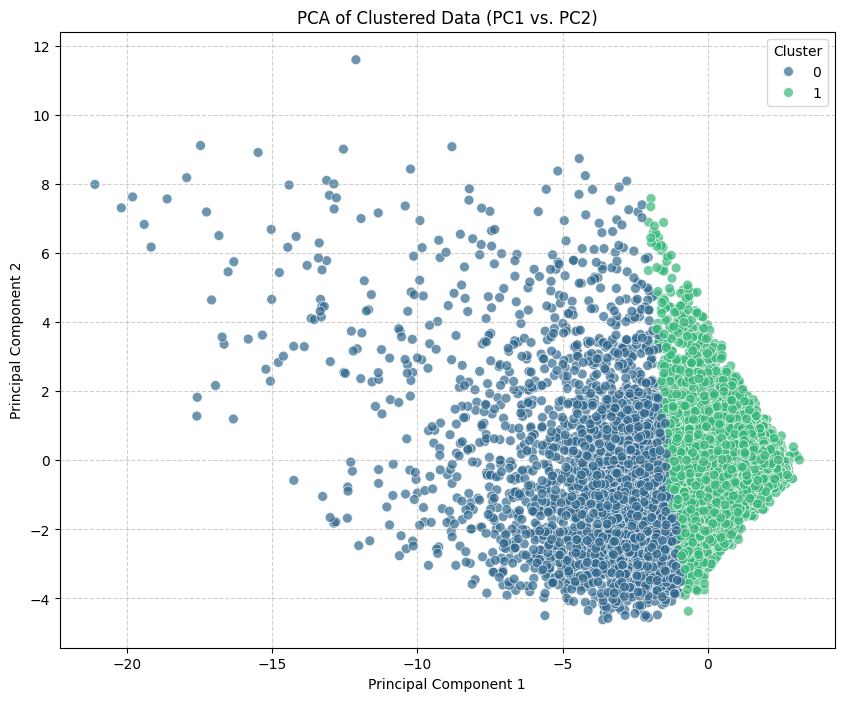

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Create a DataFrame for plotting
plot_df = pd.DataFrame(X_pca[:, :2], columns=['PC1', 'PC2'])
plot_df['Cluster'] = df_clust_cleaned['Cluster'].values
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2', hue='Cluster', data=plot_df,
    palette='viridis', legend='full', s=50, alpha=0.7
)
plt.title('PCA of Clustered Data (PC1 vs. PC2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df_clust_cleaned.drop('Cluster', axis=1)
y = df_clust_cleaned['Cluster']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets successfully.
X_train shape: (12485, 15)
X_test shape: (3122, 15)
y_train shape: (12485,)
y_test shape: (3122,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)
y_pred_log_reg = log_reg_model.predict(X_test)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log_reg))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       638
           1       0.99      1.00      0.99      2484

    accuracy                           0.99      3122
   macro avg       0.99      0.98      0.98      3122
weighted avg       0.99      0.99      0.99      3122



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Classifier Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       638
           1       0.97      0.97      0.97      2484

    accuracy                           0.96      3122
   macro avg       0.93      0.93      0.93      3122
weighted avg       0.96      0.96      0.96      3122



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Classifier Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       638
           1       0.98      0.99      0.99      2484

    accuracy                           0.98      3122
   macro avg       0.98      0.96      0.97      3122
weighted avg       0.98      0.98      0.98      3122



In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Classifier Classification Report:")
print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:20:42] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       638
           1       0.99      0.99      0.99      2484

    accuracy                           0.98      3122
   macro avg       0.98      0.97      0.98      3122
weighted avg       0.98      0.98      0.98      3122



In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Classifier Classification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       638
           1       0.99      0.99      0.99      2484

    accuracy                           0.98      3122
   macro avg       0.98      0.97      0.98      3122
weighted avg       0.98      0.98      0.98      3122



In [ ]:
import sys
!{sys.executable} -m pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.6 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report

# Initialize CatBoost Classifier model
cb_model = CatBoostClassifier(random_state=42, verbose=False)

# Fit the model to the training data
cb_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_catboost = cb_model.predict(X_test)

# Generate and print the classification report
print("CatBoost Classifier Classification Report:")
print(classification_report(y_test, y_pred_catboost))

CatBoost Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       638
           1       0.99      0.99      0.99      2484

    accuracy                           0.99      3122
   macro avg       0.98      0.98      0.98      3122
weighted avg       0.99      0.99      0.99      3122



In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("SVM Classifier Classification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       638
           1       1.00      1.00      1.00      2484

    accuracy                           1.00      3122
   macro avg       0.99      0.99      0.99      3122
weighted avg       1.00      1.00      1.00      3122



In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

ann_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
ann_model.fit(X_train, y_train)
y_pred_ann = ann_model.predict(X_test)

print("ANN Classifier Classification Report:")
print(classification_report(y_test, y_pred_ann))

ANN Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       638
           1       0.99      0.99      0.99      2484

    accuracy                           0.99      3122
   macro avg       0.99      0.99      0.99      3122
weighted avg       0.99      0.99      0.99      3122



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print("KNN Classifier Classification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.78      0.85       638
           1       0.95      0.99      0.97      2484

    accuracy                           0.94      3122
   macro avg       0.94      0.88      0.91      3122
weighted avg       0.94      0.94      0.94      3122



In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report

adaboost_model = AdaBoostClassifier(random_state=42)
adaboost_model.fit(X_train, y_train)
y_pred_adaboost = adaboost_model.predict(X_test)

print("AdaBoost Classifier Classification Report:")
print(classification_report(y_test, y_pred_adaboost))

AdaBoost Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       638
           1       0.98      0.98      0.98      2484

    accuracy                           0.97      3122
   macro avg       0.95      0.95      0.95      3122
weighted avg       0.97      0.97      0.97      3122



In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report

def get_metrics(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, output_dict=True)
    accuracy = report['accuracy']
    precision_macro = report['macro avg']['precision']
    recall_macro = report['macro avg']['recall']
    f1_macro = report['macro avg']['f1-score']
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision (Macro)': precision_macro,
        'Recall (Macro)': recall_macro,
        'F1-Score (Macro)': f1_macro
    }

metrics_data = []
metrics_data.append(get_metrics(y_test, y_pred_log_reg, 'Logistic Regression'))
metrics_data.append(get_metrics(y_test, y_pred_dt, 'Decision Tree'))
metrics_data.append(get_metrics(y_test, y_pred_rf, 'Random Forest'))
metrics_data.append(get_metrics(y_test, y_pred_xgb, 'XGBoost'))
metrics_data.append(get_metrics(y_test, y_pred_catboost, 'CatBoost'))
metrics_data.append(get_metrics(y_test, y_pred_svm, 'SVM'))
metrics_data.append(get_metrics(y_test, y_pred_ann, 'ANN'))
metrics_data.append(get_metrics(y_test, y_pred_knn, 'KNN'))
metrics_data.append(get_metrics(y_test, y_pred_adaboost, 'AdaBoost'))

df_model_comparison = pd.DataFrame(metrics_data)
display(df_model_comparison)


,Model,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,Logistic Regression,0.987828,0.985758,0.976626,0.981108
1,Decision Tree,0.956118,0.934042,0.930490,0.932252
2,Random Forest,0.981742,0.978779,0.964648,0.971510
3,XGBoost,0.984625,0.979059,0.973448,0.976221
4,CatBoost,0.987508,0.983826,0.977589,0.980669
5,SVM,0.996156,0.994090,0.994090,0.994090
6,ANN,0.991031,0.986763,0.985628,0.986194
7,KNN,0.944587,0.942566,0.883057,0.908841
8,AdaBoost,0.968930,0.954888,0.949025,0.951919


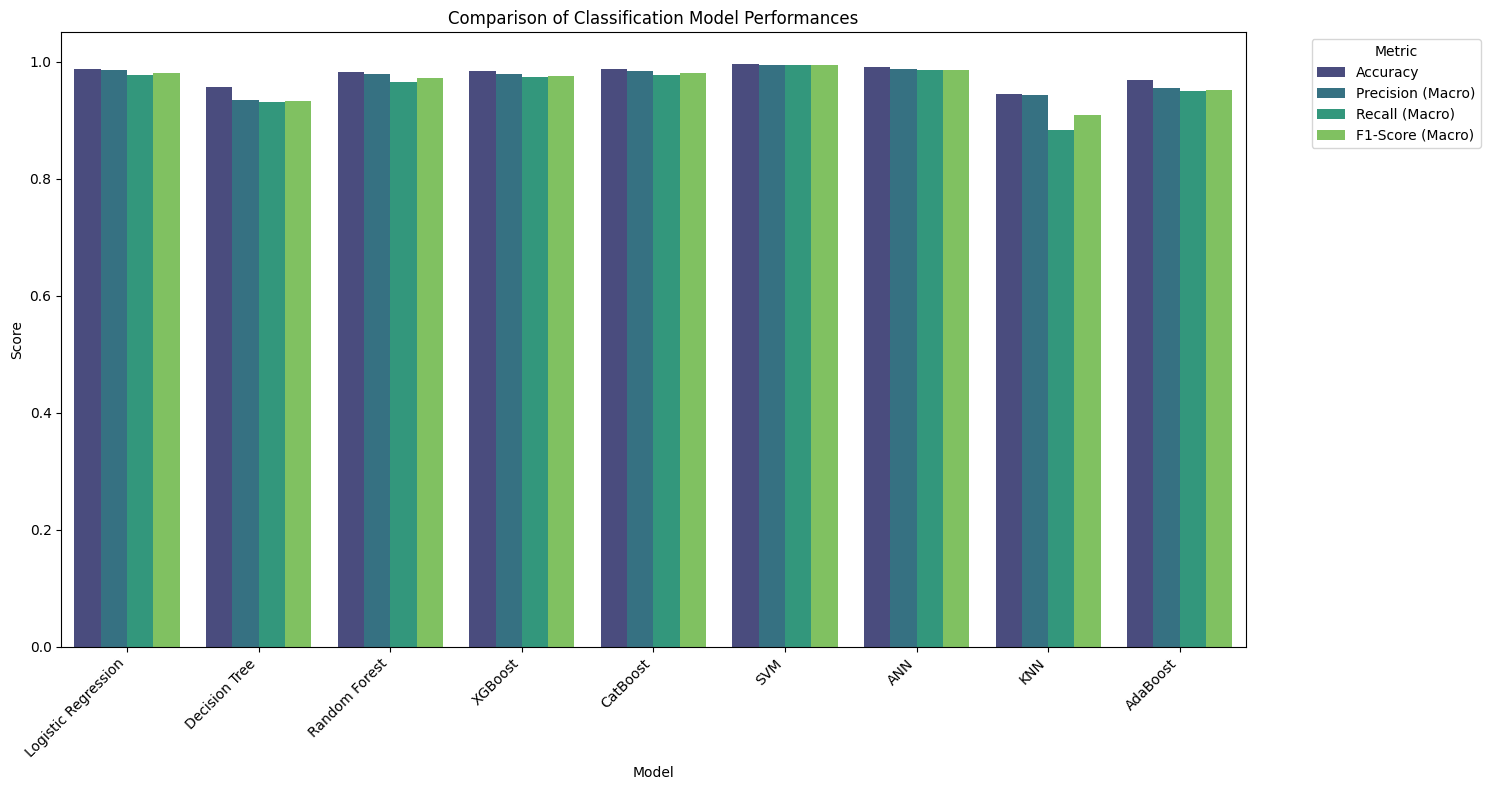

In [ ]:
df_melted = df_model_comparison.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(15, 8))
sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted, palette='viridis')
plt.title('Comparison of Classification Model Performances')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
svm_coefficients = svm_model.coef_[0]
feature_names = X_train.columns
feature_importance_svm = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': svm_coefficients
})

feature_importance_svm['Absolute_Coefficient'] = abs(feature_importance_svm['Coefficient'])
feature_importance_svm = feature_importance_svm.sort_values(by='Absolute_Coefficient', ascending=False)

print("SVM Feature Coefficients:")
print(feature_importance_svm.drop(columns=['Absolute_Coefficient']))

SVM Feature Coefficients:
             Feature  Coefficient
1              REVEL     7.849748
11            SIFT4G    -6.654165
4            DEOGEN2     5.223822
13  Polyphen2_HumVar     4.745457
10              SIFT    -4.597800
12  Polyphen2_HumDiv     4.167953
2            MetaSVM     3.557259
5          PrimateAI     3.477636
3             MetaLR     3.349720
8          phastCons     2.670818
6               DANN     1.540221
14  MutationAssessor     0.984651
9             GERP++     0.342429
0               CADD     0.292241
7             phyloP     0.257075


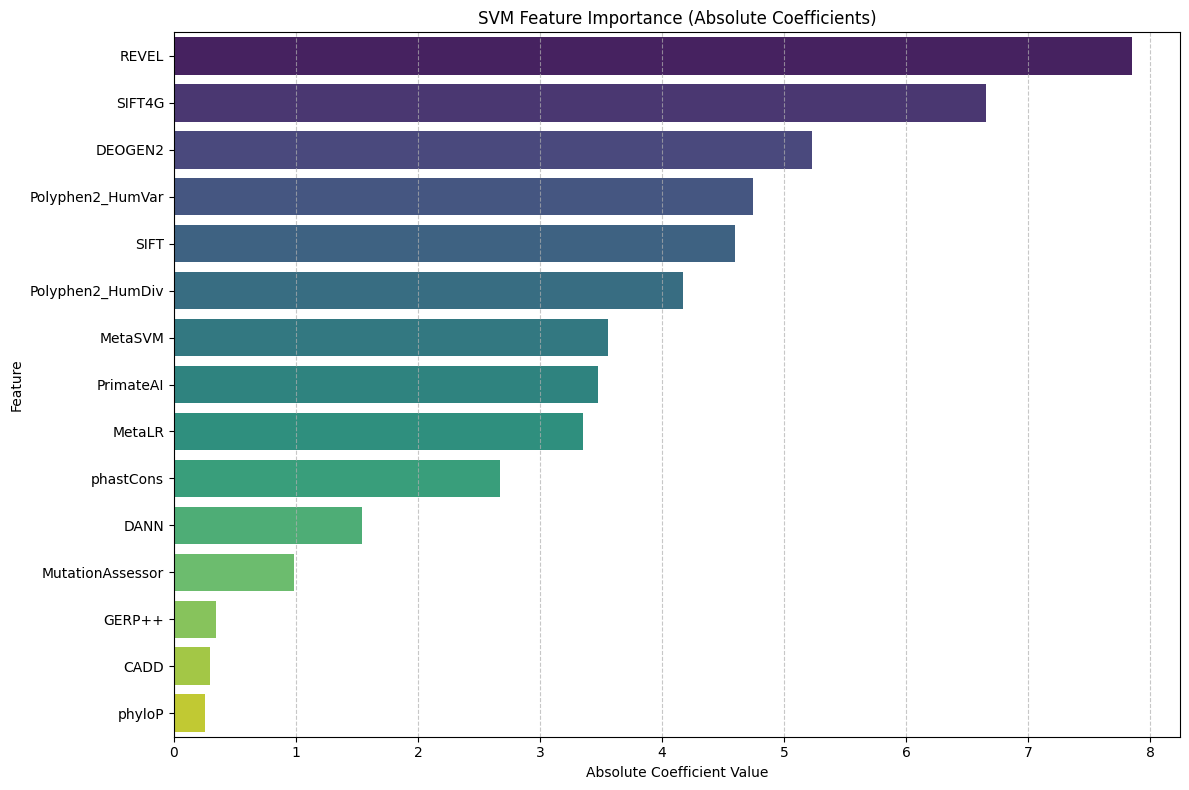

In [ ]:
N_features = len(feature_importance_svm)

plt.figure(figsize=(12, 8))
sns.barplot(x='Absolute_Coefficient', y='Feature', hue='Feature', data=feature_importance_svm.head(N_features), palette='viridis', legend=False)
plt.title('SVM Feature Importance (Absolute Coefficients)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
ensemble_cols = ['CADD', 'REVEL', 'MetaSVM']
evolution_cols = ['GERP++', 'phyloP']
structural_cols = ['SASA_unit', 'SASA_complex', 'DSSP', 'location']
biochem_cols = ['WT', 'MUT']

selected_cols = ensemble_cols + evolution_cols + structural_cols + biochem_cols

df_sub = df[selected_cols].copy()
df_sub = df_sub.rename(columns={'GERP++': 'GERP_plus_plus'})

In [ ]:
df_sub['dSASA'] = df_sub['SASA_unit'] - df_sub['SASA_complex']
df_sub.drop(columns=['SASA_unit', 'SASA_complex'], inplace=True)

In [ ]:
hydropathy = {
 'A':1.8,'R':-4.5,'N':-3.5,'D':-3.5,'C':2.5,'Q':-3.5,'E':-3.5,
 'G':-0.4,'H':-3.2,'I':4.5,'L':3.8,'K':-3.9,'M':1.9,'F':2.8,
 'P':-1.6,'S':-0.8,'T':-0.7,'W':-0.9,'Y':-1.3,'V':4.2
}

volume = {
 'A':88.6,'R':173.4,'N':114.1,'D':111.1,'C':108.5,'Q':143.8,
 'E':138.4,'G':60.1,'H':153.2,'I':166.7,'L':166.7,'K':168.6,
 'M':162.9,'F':189.9,'P':112.7,'S':89.0,'T':116.1,'W':227.8,
 'Y':193.6,'V':140.0
}

def hydro_shift(wt, mut):
    try:
        return hydropathy[mut] - hydropathy[wt]
    except:
        return np.nan

def volume_shift(wt, mut):
    try:
        return volume[mut] - volume[wt]
    except:
        return np.nan
df_sub['Hydro_shift'] = df_sub.apply(lambda r: hydro_shift(r.WT, r.MUT), axis=1)
df_sub['Volume_shift'] = df_sub.apply(lambda r: volume_shift(r.WT, r.MUT), axis=1)
df_sub.drop(columns=['WT','MUT'], inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder
# Encode DSSP
le_dssp = LabelEncoder()
df_sub['DSSP_enc'] = le_dssp.fit_transform(df_sub['DSSP'].astype(str))

# Encode structural location
le_loc = LabelEncoder()
df_sub['location_enc'] = le_loc.fit_transform(df_sub['location'].astype(str))

In [ ]:
df_sub.drop(columns=['DSSP','location'], inplace=True)

In [ ]:
import sys
!{sys.executable} -m pip install semopy
from semopy import Model
from semopy.inspector import inspect

sem_cols = [
    'CADD', 'REVEL', 'MetaSVM',
    'GERP_plus_plus', 'phyloP',
    'dSASA',
    'Hydro_shift', 'Volume_shift',
    'Cluster'
]

df_sem_temp = df_clust_cleaned.rename(columns={'GERP++': 'GERP_plus_plus'}).copy()

df_original_subset_for_eng = df.loc[df_sem_temp.index][['SASA_unit', 'SASA_complex', 'WT', 'MUT']].copy()

df_original_subset_for_eng['dSASA'] = df_original_subset_for_eng['SASA_unit'] - df_original_subset_for_eng['SASA_complex']
df_original_subset_for_eng['Hydro_shift'] = df_original_subset_for_eng.apply(lambda r: hydro_shift(r.WT, r.MUT), axis=1)
df_original_subset_for_eng['Volume_shift'] = df_original_subset_for_eng.apply(lambda r: volume_shift(r.WT, r.MUT), axis=1)
df_original_subset_for_eng.drop(columns=['SASA_unit', 'SASA_complex', 'WT', 'MUT'], inplace=True)

df_sem = pd.merge(df_sem_temp, df_original_subset_for_eng, left_index=True, right_index=True, how='inner')
df_sem = df_sem[sem_cols].dropna()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 4.4 MB/s eta 0:00:00
  Created wheel for semopy: filename=semopy-2.3.11-py3-none-any.whl size=1659682 sha256=fb23cb6ae633fa6ca95ebb2b8014b690d72ad1246442aeee7f4b8fefb4480d73
  Stored in directory: /root/.cache/pip/wheels/c6/24/8b/be911b059a61f490f38425eb19bf2fed470a5ead97228e8255
Successfully built semopy


In [ ]:
sem_desc = """
# Measurement models
Evolutionary_Constraint =~ GERP_plus_plus + phyloP
Structural_Disruption   =~ dSASA
Biochemical_Severity    =~ Hydro_shift + Volume_shift
Ensemble_Pathogenicity  =~ CADD + REVEL + MetaSVM

# Structural model
Disease_Risk =~ 1*Evolutionary_Constraint + Structural_Disruption + Biochemical_Severity + Ensemble_Pathogenicity
"""

In [ ]:
df_c0 = df_sem[df_sem['Cluster'] == 0].drop(columns='Cluster')

model_c0 = Model(sem_desc)
model_c0.fit(df_c0)

results_c0 = inspect(model_c0)
print("=== Cluster 0 SEM Results ===")
print(results_c0)

=== Cluster 0 SEM Results ===
                       lval  op                     rval      Estimate  \
0   Evolutionary_Constraint   ~             Disease_Risk  1.000000e+00   
1     Structural_Disruption   ~             Disease_Risk  1.438343e+00   
2      Biochemical_Severity   ~             Disease_Risk  2.794402e-03   
3    Ensemble_Pathogenicity   ~             Disease_Risk  2.844991e+00   
4            GERP_plus_plus   ~  Evolutionary_Constraint  1.000000e+00   
5                    phyloP   ~  Evolutionary_Constraint  1.263437e+00   
6                     dSASA   ~    Structural_Disruption  1.000000e+00   
7               Hydro_shift   ~     Biochemical_Severity  1.000000e+00   
8              Volume_shift   ~     Biochemical_Severity -9.193362e+02   
9                      CADD   ~   Ensemble_Pathogenicity  1.000000e+00   
10                    REVEL   ~   Ensemble_Pathogenicity  6.301760e-03   
11                  MetaSVM   ~   Ensemble_Pathogenicity -2.164020e-02   
12     B

In [ ]:
df_c1 = df_sem[df_sem['Cluster'] == 1].drop(columns='Cluster')

model_c1 = Model(sem_desc)
model_c1.fit(df_c1)

results_c1 = inspect(model_c1)
print("=== Cluster 1 SEM Results ===")
print(results_c1)

=== Cluster 1 SEM Results ===
                       lval  op                     rval      Estimate  \
0   Evolutionary_Constraint   ~             Disease_Risk  1.000000e+00   
1     Structural_Disruption   ~             Disease_Risk -1.015306e+02   
2      Biochemical_Severity   ~             Disease_Risk -2.163650e-01   
3    Ensemble_Pathogenicity   ~             Disease_Risk  2.883979e-02   
4            GERP_plus_plus   ~  Evolutionary_Constraint  1.000000e+00   
5                    phyloP   ~  Evolutionary_Constraint  3.986568e+00   
6                     dSASA   ~    Structural_Disruption  1.000000e+00   
7               Hydro_shift   ~     Biochemical_Severity  1.000000e+00   
8              Volume_shift   ~     Biochemical_Severity -5.623726e+02   
9                      CADD   ~   Ensemble_Pathogenicity  1.000000e+00   
10                    REVEL   ~   Ensemble_Pathogenicity  6.289745e+00   
11                  MetaSVM   ~   Ensemble_Pathogenicity  1.227549e+01   
12     B

In [ ]:
paths = [
    'Evolutionary_Constraint -> Disease_Risk',
    'Structural_Disruption -> Disease_Risk',
    'Biochemical_Severity -> Disease_Risk',
    'Ensemble_Pathogenicity -> Disease_Risk'
]

summary = pd.DataFrame({
    'Path': paths,
    'Cluster_0': [
        results_c0.query("lval=='Evolutionary_Constraint' & rval=='Disease_Risk'")['Estimate'].values[0],
        results_c0.query("lval=='Structural_Disruption' & rval=='Disease_Risk'")['Estimate'].values[0],
        results_c0.query("lval=='Biochemical_Severity' & rval=='Disease_Risk'")['Estimate'].values[0],
        results_c0.query("lval=='Ensemble_Pathogenicity' & rval=='Disease_Risk'")['Estimate'].values[0],
    ],
    'Cluster_1': [
        results_c1.query("lval=='Evolutionary_Constraint' & rval=='Disease_Risk'")['Estimate'].values[0],
        results_c1.query("lval=='Structural_Disruption' & rval=='Disease_Risk'")['Estimate'].values[0],
        results_c1.query("lval=='Biochemical_Severity' & rval=='Disease_Risk'")['Estimate'].values[0],
        results_c1.query("lval=='Ensemble_Pathogenicity' & rval=='Disease_Risk'")['Estimate'].values[0],
    ]
})

print(summary)

                                      Path  Cluster_0   Cluster_1
0  Evolutionary_Constraint -> Disease_Risk   1.000000    1.000000
1    Structural_Disruption -> Disease_Risk   1.438343 -101.530627
2     Biochemical_Severity -> Disease_Risk   0.002794   -0.216365
3   Ensemble_Pathogenicity -> Disease_Risk   2.844991    0.028840


In [ ]:
pip install semopy

In [ ]:
!pip install semopy

In [ ]:
import semopy

In [ ]:
from semopy import Model

In [ ]:
def semplot(
mod: Model, filename: str, inspection=None, plot_covs=False, plot_exos=True, images=None, engine='dot', latshape='circle', plot_ests=True, std_ests=False, show=False):
    pass

In [ ]:
from semopy import semplot

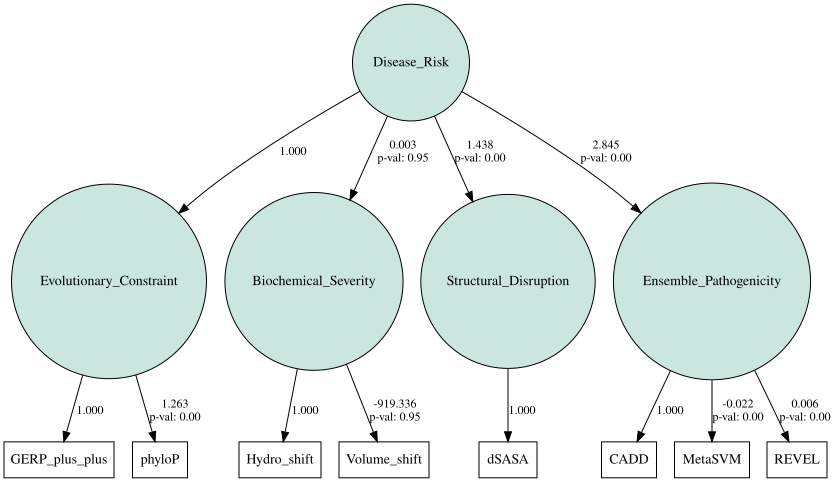

In [ ]:
semplot(
     model_c0,
     "results_c0.png",
     plot_covs=False,
     show=False
 )

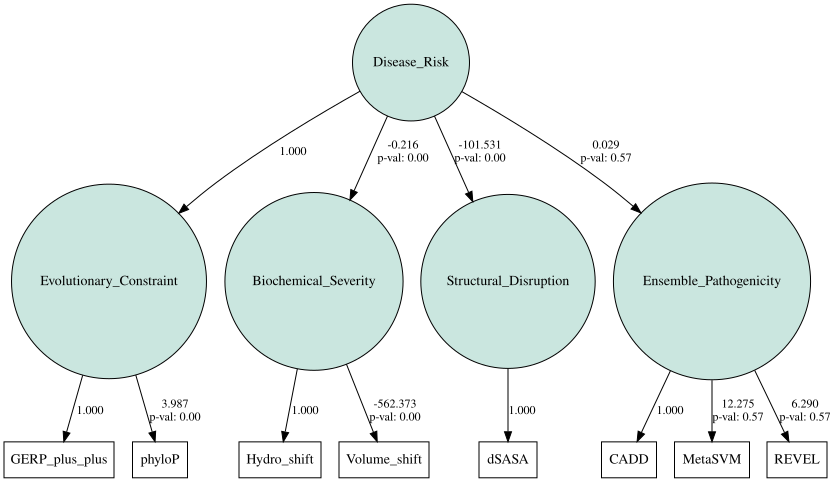

In [ ]:
semplot(
     model_c1,
     "results_c0.png", # Added .png extension
     plot_covs=False,     # hide residual covariances
     show=False           # saves figure instead of displaying
 )

In [ ]:
from semopy import utils

In [ ]:
mech_paths = [
    "Evolutionary_Constraint",
    "Structural_Disruption",
    "Biochemical_Severity",
    "Ensemble_Pathogenicity"
]

sem_mech_c0 = (
    results_c0[
        (results_c0["op"] == "~") &
        (results_c0["rval"] == "Disease_Risk") &
        (results_c0["lval"].isin(mech_paths))
    ][["lval", "Estimate", "p-value"]]
    .rename(columns={
        "lval": "Mechanism",
        "Estimate": "Cluster_0_Estimate",
        "p-value": "Cluster_0_p"
    })
)

sem_mech_c1 = (
    results_c1[
        (results_c1["op"] == "~") &
        (results_c1["rval"] == "Disease_Risk") &
        (results_c1["lval"].isin(mech_paths))
    ][["lval", "Estimate", "p-value"]]
    .rename(columns={
        "lval": "Mechanism",
        "Estimate": "Cluster_1_Estimate",
        "p-value": "Cluster_1_p"
    })
)


In [ ]:
sem_mechanism_summary = (
    sem_mech_c0
    .merge(sem_mech_c1, on="Mechanism")
)
sem_mechanism_summary


,Mechanism,Cluster_0_Estimate,Cluster_0_p,Cluster_1_Estimate,Cluster_1_p
0,Evolutionary_Constraint,1.000000,-,1.000000,-
1,Structural_Disruption,1.438343,0.000341,-101.530627,0.00001
2,Biochemical_Severity,0.002794,0.948071,-0.216365,0.000003
3,Ensemble_Pathogenicity,2.844991,0.000086,0.028840,0.570893


In [ ]:
sem_mechanism_summary["Abs_C0"] = sem_mechanism_summary["Cluster_0_Estimate"].abs()
sem_mechanism_summary["Abs_C1"] = sem_mechanism_summary["Cluster_1_Estimate"].abs()

sem_mechanism_summary.sort_values(
    ["Abs_C1", "Abs_C0"],
    ascending=False
)


,Mechanism,Cluster_0_Estimate,Cluster_0_p,Cluster_1_Estimate,Cluster_1_p,Abs_C0,Abs_C1
1,Structural_Disruption,1.438343,0.000341,-101.530627,0.00001,1.438343,101.530627
0,Evolutionary_Constraint,1.000000,-,1.000000,-,1.000000,1.000000
2,Biochemical_Severity,0.002794,0.948071,-0.216365,0.000003,0.002794,0.216365
3,Ensemble_Pathogenicity,2.844991,0.000086,0.028840,0.570893,2.844991,0.028840


In [ ]:
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names,
    name="RF_Importance"
)

In [ ]:
svm_importance = pd.Series(
    np.abs(svm_model.coef_[0]),
    index=feature_names,
    name="SVM_Importance"
)

In [ ]:
rf_norm = rf_importance / rf_importance.sum()
svm_norm = svm_importance / svm_importance.sum()


In [ ]:
consensus_importance = pd.concat(
    [rf_norm, svm_norm],
    axis=1
)
consensus_importance["Consensus_Score"] = (
    consensus_importance["RF_Importance"] +
    consensus_importance["SVM_Importance"]
) / 2
consensus_importance = consensus_importance.sort_values(
    "Consensus_Score",
    ascending=False
)
consensus_importance


,RF_Importance,SVM_Importance,Consensus_Score
REVEL,0.224122,0.157908,0.191015
MetaSVM,0.167297,0.071559,0.119428
Polyphen2_HumVar,0.103381,0.095461,0.099421
MetaLR,0.109504,0.067384,0.088444
SIFT4G,0.038035,0.133857,0.085946
Polyphen2_HumDiv,0.083519,0.083844,0.083681
DEOGEN2,0.048061,0.105084,0.076572
SIFT,0.024411,0.092491,0.058451
PrimateAI,0.016219,0.069957,0.043088
MutationAssessor,0.055125,0.019808,0.037466


In [ ]:
mechanism_map = {
    'CADD': 'Ensemble_Pathogenicity',
    'REVEL': 'Ensemble_Pathogenicity',
    'MetaSVM': 'Ensemble_Pathogenicity',
    'GERP++': 'Evolutionary_Constraint',
    'phyloP': 'Evolutionary_Constraint'
}
consensus_importance['Mechanism'] = consensus_importance.index.map(mechanism_map)

mechanism_consensus = (
    consensus_importance
    .dropna(subset=["Mechanism"])
    .groupby("Mechanism")["Consensus_Score"]
    .sum()
    .sort_values(ascending=False)
)
mechanism_consensus

,Consensus_Score
Mechanism,
Ensemble_Pathogenicity,0.344025
Evolutionary_Constraint,0.026147


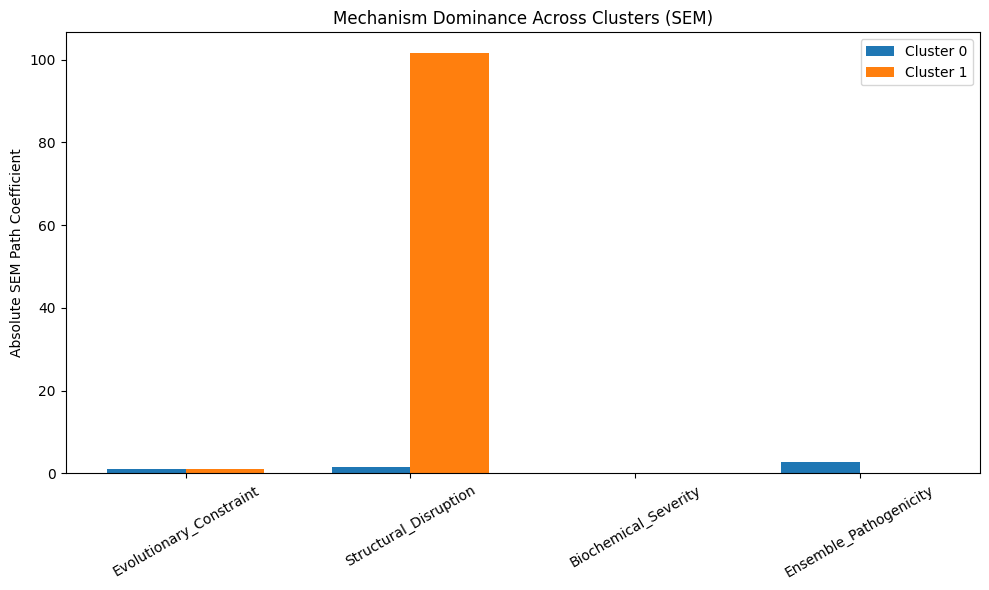

In [ ]:
plot_df = sem_mechanism_summary.set_index("Mechanism")
x = np.arange(len(plot_df.index))
width = 0.35
plt.figure(figsize=(10, 6))
plt.bar(
    x - width/2,
    plot_df["Cluster_0_Estimate"].abs(),
    width,
    label="Cluster 0"
)
plt.bar(
    x + width/2,
    plot_df["Cluster_1_Estimate"].abs(),
    width,
    label="Cluster 1"
)
plt.xticks(x, plot_df.index, rotation=30)
plt.ylabel("Absolute SEM Path Coefficient")
plt.title("Mechanism Dominance Across Clusters (SEM)")
plt.legend()
plt.tight_layout()
plt.show()

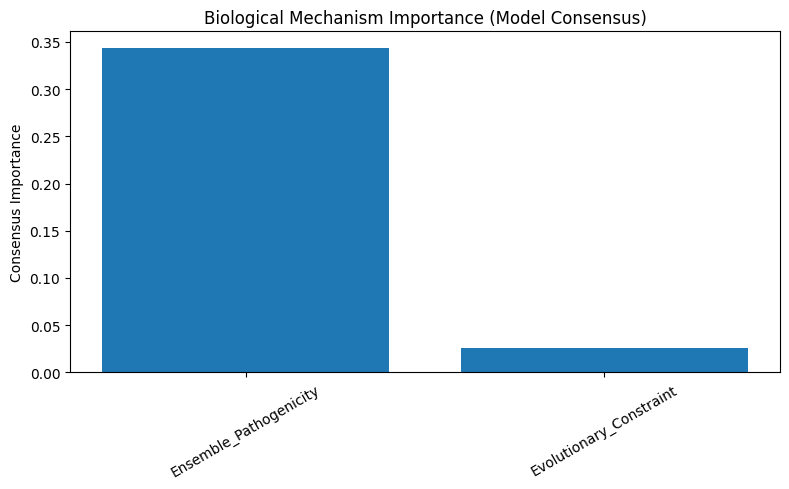

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(
    mechanism_consensus.index,
    mechanism_consensus.values
)
plt.ylabel("Consensus Importance")
plt.title("Biological Mechanism Importance (Model Consensus)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


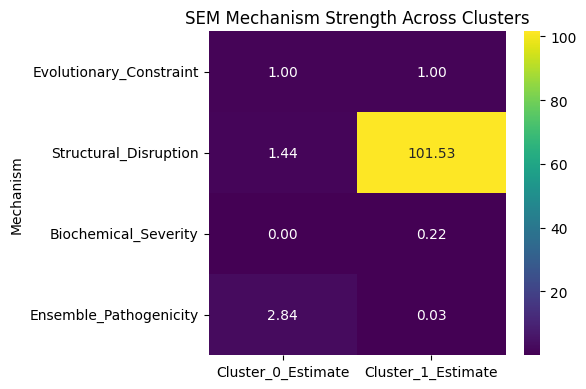

In [ ]:
import seaborn as sns

heatmap_df = sem_mechanism_summary.set_index("Mechanism")[
    ["Cluster_0_Estimate", "Cluster_1_Estimate"]
]
heatmap_df = heatmap_df.abs()
plt.figure(figsize=(6, 4))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)
plt.title("SEM Mechanism Strength Across Clusters")
plt.tight_layout()
plt.show()

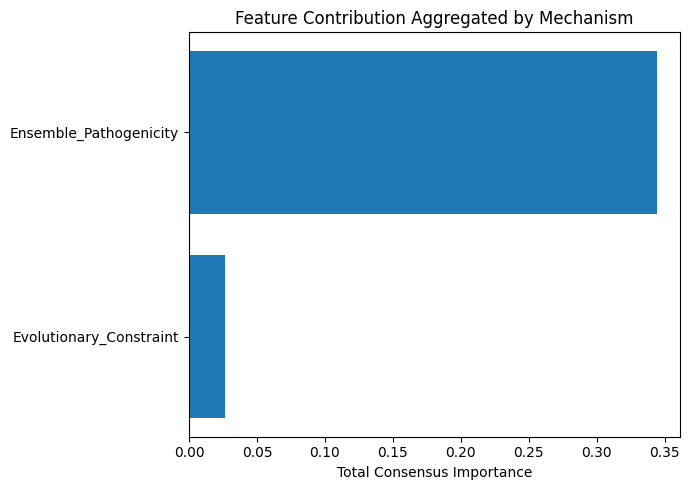

In [ ]:
mech_feature = (
    consensus_importance
    .dropna(subset=["Mechanism"])
    .groupby("Mechanism")["Consensus_Score"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(7, 5))
plt.barh(
    mech_feature.index,
    mech_feature.values
)

plt.xlabel("Total Consensus Importance")
plt.title("Feature Contribution Aggregated by Mechanism")
plt.tight_layout()
plt.show()


GENE-LEVEL MECHANISTIC STRATIFICATION

In [ ]:
#['Gene', 'Cluster', 'CADD', 'REVEL', 'MetaSVM', 'GERP++', 'phyloP', 'dSASA']
gene_df = df_clust_cleaned.copy()
gene_df = gene_df.merge(df[['gene']], left_index=True, right_index=True, how='left')
gene_df = gene_df.rename(columns={'gene': 'Gene'})
gene_df = gene_df.merge(df[['SASA_unit', 'SASA_complex']], left_index=True, right_index=True, how='left')
gene_df['dSASA'] = gene_df['SASA_unit'] - gene_df['SASA_complex']
gene_df.drop(columns=['SASA_unit', 'SASA_complex'], inplace=True)

gene_df['Ensemble_score'] = gene_df[['CADD','REVEL','MetaSVM']].mean(axis=1)
gene_df['Constraint_score'] = gene_df[['GERP++','phyloP']].mean(axis=1)
gene_df['Structural_score'] = gene_df['dSASA'].abs()

gene_summary = (
    gene_df
    .groupby('Gene')
    .agg(
        N_variants=('Cluster','size'),
        frac_cluster1=('Cluster', lambda x: (x==1).mean()),
        Mean_Ensemble=('Ensemble_score','mean'),
        Mean_Constraint=('Constraint_score','mean'),
        Mean_Structural=('Structural_score','mean')
    )
)

def dominant_mechanism(row):
    vals = {
        'Prediction-driven': row['Mean_Ensemble'],
        'Constraint-driven': row['Mean_Constraint'],
        'Structure-driven': row['Mean_Structural']
    }
    return max(vals, key=vals.get)

gene_summary['Dominant_Mechanism'] = gene_summary.apply(dominant_mechanism, axis=1)

gene_summary.sort_values('frac_cluster1', ascending=False).head()

,N_variants,frac_cluster1,Mean_Ensemble,Mean_Constraint,Mean_Structural,Dominant_Mechanism
Gene,,,,,,
ABCA1,8,1.0,11.111000,6.827812,0.537500,Prediction-driven
ZMPSTE24,2,1.0,9.894383,6.315500,0.000000,Prediction-driven
AARS,6,1.0,10.607926,6.195722,2.616667,Prediction-driven
XDH,1,1.0,12.273400,6.743500,228.000000,Structure-driven
WNT3,1,1.0,11.569600,6.251000,0.000000,Prediction-driven


VARIANT-LEVEL MECHANISM LABELING

In [ ]:
variant_df = df_clust_cleaned.copy()
variant_df = variant_df.merge(df[['gene']], left_index=True, right_index=True, how='left')
variant_df = variant_df.rename(columns={'gene': 'Gene'})

variant_df = variant_df.merge(df[['SASA_unit', 'SASA_complex']], left_index=True, right_index=True, how='left')
variant_df['dSASA'] = variant_df['SASA_unit'] - variant_df['SASA_complex']
variant_df.drop(columns=['SASA_unit', 'SASA_complex'], inplace=True)

variant_df['Ensemble_score'] = variant_df[['CADD','REVEL','MetaSVM']].mean(axis=1)
variant_df['Constraint_score'] = variant_df[['GERP++','phyloP']].mean(axis=1)
variant_df['Structural_score'] = variant_df['dSASA'].abs()

def variant_mechanism(row):
    scores = {
        'Prediction-driven': row['Ensemble_score'],
        'Constraint-driven': row['Constraint_score'],
        'Structure-driven': row['Structural_score']
    }
    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    if sorted_scores[0][1] - sorted_scores[1][1] < 0.1:
        return 'Hybrid'
    return sorted_scores[0][0]

variant_df['Variant_Mechanism'] = variant_df.apply(variant_mechanism, axis=1)

variant_df[['Gene','Cluster','Variant_Mechanism']].head()

,Gene,Cluster,Variant_Mechanism
0,CRPPA,1,Structure-driven
1,CRPPA,1,Prediction-driven
2,CRPPA,0,Prediction-driven
3,CRPPA,1,Prediction-driven
4,CRPPA,1,Prediction-driven


WHY SVM WORKS (LINEAR SEPARABILITY ANALYSIS)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

pca_df = pd.DataFrame(X_pca[:, :2], columns=['PC1','PC2'])
pca_df['Cluster'] = df_clust_cleaned['Cluster'].values

centroids = pca_df.groupby('Cluster')[['PC1','PC2']].mean()
centroid_distance = pairwise_distances(centroids)[0,1]

spread = (
    pca_df
    .groupby('Cluster')[['PC1','PC2']]
    .apply(lambda x: np.mean(pairwise_distances(x)))
)

svm_separability = {
    'Centroid_Distance': centroid_distance,
    'Spread_Cluster0': spread.loc[0],
    'Spread_Cluster1': spread.loc[1],
    'Separation_Ratio': centroid_distance / (spread.mean())
}
svm_separability


{'Centroid_Distance': np.float64(4.65283140734783),
 'Spread_Cluster0': np.float64(4.118208887414243),
 'Spread_Cluster1': np.float64(1.7274490253308212),
 'Separation_Ratio': np.float64(1.5918931544740038)}